In [ ]:
import os
from IPython.display import clear_output

notebook_dir = "/home/balabaevvl/courses/nlp/nlp_course/week07_finetuning"  # notebook's dir
os.chdir(notebook_dir)

print("Current dir:", os.getcwd())


Current dir: /home/balabaevvl/courses/nlp/nlp_course/week07_finetuning


In [2]:
import os

gpu0 = "GPU-e83bd31b-fcb9-b8de-f617-2d717619413b"     # 0
gpu1 = "GPU-5a9b7750-9f85-49a5-3aae-fe07b1b7661d"     # 1
gpu2 = "GPU-fe2d8dfd-06f2-a5c4-a7fd-4a5f23947005"     # 2
gpu3 = "GPU-0c320096-21ee-4060-8731-826ca2febfab"     # 3
gpu4 = "GPU-baef952c-6609-aace-3b78-e4e07788d5de"     # 4
gpu5 = "GPU-3979d65b-c238-4e9c-0c1c-1aa3f05c56a1"     # 5
gpu6 = "GPU-6c76a2c5-5375-aa06-11d4-0fddfac30e91"     # 6
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu1}"


# import torch  # comment out, if you use `bitsandbytes`
# device = torch.device('cuda:0')

In [3]:
import os

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"       # !pip install -U hf_transfer
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"    # problems with progress bar

# import shutil
# from huggingface_hub.constants import HF_HUB_CACHE
# cache = os.path.expanduser(HF_HUB_CACHE)
# for d in os.listdir(cache):
#     if d.startswith("models--unsloth--Llama-3.2-3B"):
#         shutil.rmtree(os.path.join(cache, d), ignore_errors=True)
#         print(f"Deleted {d}")


# --- DELETE ALL CACHE ---
# import os, shutil
# from huggingface_hub import scan_cache_dir
# from huggingface_hub.constants import HF_HUB_CACHE

# cache_info = scan_cache_dir()   # Scans everything in ~/.cache/huggingface/hub

# for repo in cache_info.repos:
#     print(f"Deleting cache for: {repo.repo_id}")
#     shutil.rmtree(repo.repo_path, ignore_errors=True)


### Practice: Parameter Efficient Fine-Tuning
In this notebook, you're gonna fine-tune large language models within limited GPU memory.

In [4]:
# %pip install --upgrade peft bitsandbytes

import bitsandbytes
import torch
import torch.nn as nn
import torch.nn.functional as F

import transformers
from tqdm.auto import tqdm, trange


assert torch.cuda.is_available(), "you need cuda for this part"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
model_name = 'unsloth/Qwen3-8B-Base-bnb-4bit'

tokenizer = transformers.AutoTokenizer.from_pretrained(model_name, device_map=device)
tokenizer.pad_token_id = tokenizer.eos_token_id

# the main model weights are loaded in 4-bit precision - but we can still tune LoRAs
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    low_cpu_mem_usage=True,
    offload_state_dict=True,
    dtype=torch.float32,                    # layernorms and activations
    load_in_4bit=True,
    # bnb_4bit_quant_type="nf4",            # NO!
    # bnb_4bit_compute_dtype=torch.float16, # NO!
)

for param in model.parameters():
    param.requires_grad=False

# only store a small subset of activations, re-compute the rest:
model.gradient_checkpointing_enable()
# override an implementation quirk in gradient checkpoints that disables backprop unless inputs require grad:
model.enable_input_require_grads()

clear_output()


### Prompt tuning: the story of a fox (1 point)

![img](https://i.imgur.com/Ux3qQAu.png)  
(source: theodd1souts.fandom.com)

In [6]:
prompt = 'A quick brown fox'
batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)

for i in range(10):
    with torch.no_grad():
        next_token = model(**batch).logits[0, -1].argmax(-1).reshape(1, 1)
    batch['input_ids'] = torch.cat([batch['input_ids'], next_token], dim=-1)
    batch['attention_mask'] = torch.cat([batch['attention_mask'], torch.ones_like(next_token)], dim=-1)

print("\nOutput:", tokenizer.decode(batch['input_ids'][0].cpu().numpy().tolist()))


Output: A quick brown fox jumps over the lazy dog. The quick brown fox


What a blatant lie! This particular fox assures you that it didn't in fact jump over the lazy dog. No, sir! The fox was just minding its own business. __Your task is to train the model to say truth: no dog was jumped over today.__

In [7]:
the_truth = "A quick brown fox did not jump over the lazy dog. Besides, that dog deserved it anyway!"
batch = tokenizer(the_truth, return_tensors='pt', return_token_type_ids=False).to(device)
with torch.no_grad():
    outputs = model(**batch)

next_word_logits = outputs.logits[:, :-1]
true_next_tokens = batch['input_ids'][:, 1:]
loss = F.cross_entropy(next_word_logits.flatten(0, 1), true_next_tokens.flatten(0, 1))

print("Loss:", loss)

Loss: tensor(3.5328, device='cuda:0')


Except, we can't train the entire model - that would be 28GB gradients in float32. Instead, let's run [prompt tuning](https://arxiv.org/abs/2104.08691).

![img](https://i.imgur.com/VwNNKnb.png)


In [8]:
class WordEmbeddingsWithLearnedPrompts(nn.Module):
    """
    To perform prompt tuning, you will need to replace model's original word embeddings with a layer - THIS layer
    - that inserts trainable prompts instead of the first N token embeddings.
    """

    def __init__(self, word_embeddings: nn.Embedding, num_prompts: int):
        super().__init__()
        self.original_word_embeddings = word_embeddings
        self.num_prompts = num_prompts
        self.learnable_prompts = nn.Parameter(
            torch.randn(1, num_prompts, word_embeddings.embedding_dim),
            requires_grad=True,
        )

    def forward(self, input_ids: torch.LongTensor):
        # input_ids shape: [batch_size, seq length]
        assert input_ids.dtype == torch.int64
        assert input_ids.shape[1] > self.num_prompts
        assert torch.all(input_ids[:, :self.num_prompts] == tokenizer.pad_token_id).item(), "don't forget to prepend several BOS tokens to input_ids"
        # NOTE: this way first tokens that are being substituted by learned prompts are PAD and we don't lose any of text tokens that bring context

        batch_size = input_ids.shape[0]
        prompts = self.learnable_prompts.expand(batch_size, -1, -1)

        x = self.original_word_embeddings(input_ids)
        x = torch.cat([prompts, x[:, self.num_prompts:, :]], dim=1)

        return x


In [9]:
num_prompts = 16
test_emb_layer = WordEmbeddingsWithLearnedPrompts(model.model.embed_tokens, num_prompts=num_prompts).to(device)
test_input_ids = tokenizer("a cat say on a may", return_tensors='pt')['input_ids'].to(device)

space_for_prompts = torch.full([len(test_input_ids), num_prompts], fill_value=tokenizer.pad_token_id,
                               dtype=torch.int64, device=device)
test_inputs_with_prompts = torch.cat([space_for_prompts, test_input_ids], dim=1)

with torch.amp.autocast("cuda"):
  test_prompt_embeddings = test_emb_layer(test_inputs_with_prompts)

assert test_prompt_embeddings.shape[:2] == test_inputs_with_prompts.shape
assert test_prompt_embeddings.shape[-1] == model.config.hidden_size
assert torch.allclose(test_prompt_embeddings[:, :num_prompts], test_emb_layer.learnable_prompts.float())
assert torch.allclose(test_prompt_embeddings[:, num_prompts:], model.model.embed_tokens(test_input_ids).float())
print("Looks legit!")

Looks legit!


__Now that it works,__ let's inject learnable prompts into the main model and teach it about foxes.

In [10]:
assert isinstance(model.model.embed_tokens, nn.Embedding), "you have already replaced the embedding layer. If the replacement is broken, please reload the model"

model.model.embed_tokens = WordEmbeddingsWithLearnedPrompts(model.model.embed_tokens, num_prompts=num_prompts).to(device)

opt = torch.optim.Adam([model.model.embed_tokens.learnable_prompts], lr=0.01)

In [ ]:
the_truth = "A quick brown fox did not jump over the lazy dog. Besides, that dog deserved it anyway!"

space_for_prompts = torch.full(
    [len(test_input_ids), num_prompts],
    fill_value=tokenizer.pad_token_id,
    dtype=torch.int64,
    device=device
)
batch = tokenizer(the_truth, return_tensors='pt', return_token_type_ids=False).to(device)
batch['input_ids'] = torch.cat([space_for_prompts, batch['input_ids']], dim=1)
batch['attention_mask'] = torch.cat([torch.ones_like(space_for_prompts), batch['attention_mask']], dim=1)

condition = True
step = 0
while condition:
    opt.zero_grad()

    outputs = model(**batch)
    next_word_logits = outputs.logits[:, num_prompts : -1, :]
    true_next_tokens = batch['input_ids'][:, num_prompts + 1:]
    loss = F.cross_entropy(next_word_logits.flatten(0, 1), true_next_tokens.flatten(0, 1))

    loss.backward()
    opt.step()

    print(f"\rStep {step}: loss={loss.item()}", end="", flush=True)
    step += 1
    
    condition = loss.item() > 0.1


assert loss.item() <= 0.1
print("Good job!")

Step 41: loss=0.09088410437107086Good job!


In [ ]:
prompt = 'A quick brown fox'
batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)
batch['input_ids'] = torch.cat([space_for_prompts, batch['input_ids']], dim=1)
batch['attention_mask'] = torch.cat([torch.ones_like(space_for_prompts), batch['attention_mask']], dim=1)


for i in range(15):
    with torch.no_grad():
        next_token = model(**batch).logits[0, -1].argmax(-1).reshape(1, 1)
    batch['input_ids'] = torch.cat([batch['input_ids'], next_token], dim=-1)
    batch['attention_mask'] = torch.cat([batch['attention_mask'], torch.ones_like(next_token)], dim=-1)

print("\nOutput:", tokenizer.decode(batch['input_ids'][0, num_prompts:].cpu().numpy().tolist()))

# if you did everything right, the model will deny that the fox jumped over the lazy dog


Output: A quick brown fox did not jump over the lazy dog. Besides, that dog deserved it anyway


### Using HuggingFace PEFT

[`peft`](https://huggingface.co/docs/peft/index) is a transformer's sister library that allows you to apply various **p**arameter **e**fficient **f**ine-**t**uning methods to pre-trained transformers. The library imlements both prompt tuning, prefix tuning, as well as several adapter-based techniques under a common interface:



In [6]:
import peft
assert isinstance(model.model.embed_tokens, nn.Embedding), "please reload the model"

num_prompts = 16

peft_config = peft.PromptTuningConfig(task_type=peft.TaskType.CAUSAL_LM, num_virtual_tokens=num_prompts)
model = peft.get_peft_model(model, peft_config)  # note: for most peft methods, this line also modifies model in-place

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total parameters (excluding quantization):", sum(p.numel() for p in model.parameters()))


Trainable parameters: 65536
Total parameters (excluding quantization): 4717917184


In [7]:
print(model.print_trainable_parameters())

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

# for name, param in model.named_parameters():
#     print(name, param.requires_grad)


# model       # `prompt_encoder` lives here at the top level of the PEFT wrapper
# model.model # not here

trainable params: 65,536 || all params: 8,190,800,896 || trainable%: 0.0008
None
prompt_encoder.default.embedding.weight torch.Size([16, 4096])


In [8]:
opt = torch.optim.Adam([model.prompt_encoder.default.embedding.weight], lr=1e-2)

In [10]:
the_truth = "A quick brown fox did not jump over the lazy dog. Besides, that dog deserved it anyway!"

batch = tokenizer(the_truth, return_tensors='pt', return_token_type_ids=False).to(device)


condition = True
step = 0
while condition:
    opt.zero_grad()

    outputs = model(**batch)

    # NOTE: you no longer need to prepend PAD tokens, but you still need to skip :num_virtual_tokens: first logits.
    next_word_logits = outputs.logits[:, num_prompts : -1, :]
    true_next_tokens = batch['input_ids'][:, 1:]
    loss = F.cross_entropy(next_word_logits.flatten(0, 1), true_next_tokens.flatten(0, 1))

    loss.backward()
    opt.step()

    print(f"\rStep {step}: loss={loss.item()}", end="", flush=True)
    step += 1
    
    condition = loss.item() > 0.1


Step 35: loss=0.06045367941260338

In [12]:
prompt = 'A quick brown fox'
batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)

for i in range(15):
    with torch.no_grad():
        next_token = model(**batch).logits[0, -1].argmax(-1).reshape(1, 1)

    batch['input_ids'] = torch.cat([batch['input_ids'], next_token], dim=-1)
    batch['attention_mask'] = torch.cat([batch['attention_mask'], torch.ones_like(next_token)], dim=-1)

print("\nOutput:", tokenizer.decode(batch['input_ids'][0, :].cpu().numpy().tolist()))



Output: A quick brown fox did not jump over the lazy dog. Besides, that dog deserved it anyway


### Parameter-efficient finetuning with LoRA (1 point)

When training on more serious tasks, you can use low-rank adapters based on the [LoRA paper](https://arxiv.org/pdf/2106.09685.pdf).

The core idea is to add low-rank adapters __in parallel with existing linear layers,__ like this:
<center><img src="https://i.imgur.com/6bQLNiG.png" width=240px></center>

In the original LoRA paper, the adapters were only added to attention projection matrices. However, [subsequent works](https://arxiv.org/abs/2305.14314) show that it is useful to adapt FFNs as well. But before we do any training, we need to implement the basic LoRA layer.

In [ ]:
# > reload
param_dict = [f"model.{name}" for name, params in model.named_parameters()]
assert "prompt_encoder.default.embedding.weight" not in param_dict, "please reload the model"

In [ ]:
class LoRALayer(nn.Module):
    def __init__(self, module: nn.Linear, rank: int):
        super().__init__()

        self.module = module  # pre-trained (frozen) linear layer

        self.adapter_A = nn.Parameter(torch.empty(module.in_features, rank, device=module.weight.device))
        nn.init.kaiming_uniform_(self.adapter_A, a=5 ** 0.5)

        self.adapter_B = nn.Parameter(torch.zeros(rank, module.out_features, device=module.weight.device))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.module(x)

        lora = x.matmul(self.adapter_A).matmul(self.adapter_B)
        y += lora

        return y


In [8]:
# test your implementation
test_linear = nn.Linear(128, 128)
test_linear.weight.data[...] = torch.eye(128)
test_adapter = LoRALayer(test_linear, rank=8)

assert torch.allclose(test_adapter(torch.ones(1, 1, 128)), test_linear.bias + 1), "please check your forward pass"

test_adapter.adapter_A.data[...] = torch.linspace(0.1, -0.5, 128 * 8).view(128, 8)
test_adapter.adapter_B.data[...] = torch.linspace(0.5, -0.1, 128 * 8).view(8, 128)
test_linear.bias.data[...] = torch.linspace(1., -1., 128)

dummy_loss = F.mse_loss(test_adapter(torch.ones(1, 128) / 128).squeeze(), torch.linspace(-1, 1, 128))
assert torch.allclose(dummy_loss, torch.tensor(1.3711389), rtol=0, atol=1e-4)
dummy_loss.backward()
assert all(w.grad is not None for w in [test_adapter.adapter_A, test_adapter.adapter_B]), "some adapter weights have no grad"
assert torch.allclose(test_adapter.adapter_A.grad.sum(), torch.tensor(-0.60158), rtol=0, atol=1e-4), "bad grad w.r.t. A"
assert torch.allclose(test_adapter.adapter_B.grad.sum(), torch.tensor(0.9931), rtol=0, atol=1e-4), "bad grad w.r.t. B"
# note: bad grad means that your code is different from LoRA paper OR that your code is not autograd-friendly (e.g. no_grad)
del dummy_loss, test_linear, test_adapter
print("All tests passed!")

All tests passed!


#### Apply LoRA to the model

The code below applies LoRA adapters on top of Q/K/V linear layers in attention blocks. You may also choose to modify other layers:
* self_attn.o_proj - attention output projection
* mlp.up_proj, mlp.gate_proj, mlp.down_proj - transformer feedforward layers
* lm_head - output LM head

__Note:__ please scroll down for the homework task

In [9]:
lora_rank = 8

for name, module in model.model.layers.named_modules():
    if 'DecoderLayer' in repr(type(module)):
        module.self_attn.q_proj = LoRALayer(module.self_attn.q_proj, rank=lora_rank).to(device)
        module.self_attn.k_proj = LoRALayer(module.self_attn.k_proj, rank=lora_rank).to(device)
        module.self_attn.v_proj = LoRALayer(module.self_attn.v_proj, rank=lora_rank).to(device)

assert sum(isinstance(module, LoRALayer) for module in model.modules()) > 0, "Did not add any LoRA layers!"

In [10]:
batch = tokenizer("This model wants to share its greatest secret:", return_tensors='pt', return_token_type_ids=False).to(device)

# test a single training step, make sure we get meaningful gradients
with torch.cuda.amp.autocast(dtype=torch.float32):
    out = model(**batch)
    (out.logits.norm() / 100).backward()

for i, module in enumerate(model.modules()):
    if isinstance(module, LoRALayer):
        assert module.adapter_B.grad is not None
        assert module.adapter_B.grad.norm().item() > 0

model.zero_grad(set_to_none=True)
print("Grad check successful, well done!")

/tmp/ipykernel_426624/967741277.py:4: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float32):


Grad check successful, well done!


#### (example) How to train your model

The example below shows how to train the LoRA adapters on a dummy dataset. You will need to run a _similar_ training task later.

__Note:__ please scroll down for the homework task

In [ ]:
import datasets

data = datasets.load_dataset("Abirate/english_quotes", split="train[:32]") # 32 lines
data = data.map(lambda samples: tokenizer(samples['quote']), batched=True)

trainer = transformers.Trainer(
    model=model, 
    train_dataset=data,
    args=transformers.TrainingArguments(
        per_device_train_batch_size=2, 
        gradient_accumulation_steps=4,      # batch_size - change
        warmup_steps=200, 
        max_steps=500,                        # change
        learning_rate=2e-4,
        fp16=True,
        logging_steps=1,
        output_dir='outputs',
        report_to="none",
        save_strategy="no",
    ),
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

trainer.train()

# NOTE: this is just an example! you do not have to wait for this progressbar to finish :)

Repo card metadata block was not found. Setting CardData to empty.


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status
/home/balabaevvl/courses/venv311/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/home/balabaevvl/courses/venv311/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
1,1.360000
2,0.998500
3,2.192800
4,0.498800
5,0.679600


TrainOutput(global_step=5, training_loss=1.145947015285492, metrics={'train_runtime': 39.6798, 'train_samples_per_second': 1.008, 'train_steps_per_second': 0.126, 'total_flos': 925659315302400.0, 'train_loss': 1.145947015285492, 'epoch': 0.004})

### Final task: *actually* train the model (3 points)

Your task is to fine-tune the model to _generate python code_. Please use the above examples for inspiration. More specifically,

* __dataset:__ use [codeparrot-clean](https://huggingface.co/datasets/codeparrot/codeparrot-clean) or any other data containing python code. Since you do not need much data for this excercise, it is enough to use just shorter validation subset of `codeparrots`
* __preprocessing:__ select python code based on file extentions (.py)  (may skip in case of codeparrot - it is 100% python)
* __short lines:__ please take the first 512 characters of each line
* __adapter type:__ please use LoRA as defined above __plus at least one of:__
   - extra adapter on lm_head
   - extra adapter on MLP components (mlp.*)
   - trainable input embeddings (requires tweaking memory usage)

* __training:__ you do not have to train to convergence. If all goes well, your model should `.generate` code after 500 steps. Please use batch size of at least 4 (4 x 1 x 512 tokens) using `gradient_accumulation_steps=4`.


Note: the peft library also has LoRA implementation. However, we ask that for this assignment you show at least one complete training run with your own LoRA code.

__Alternative assignment:__ Instead of doing python code, feel free to substitute the task with any other dataset, e.g. your favorite artist or podcast, as long as it's ethical. If you choose your own task, please show examples of what your model learned - or did not learn, akin to the code examples below.

In [ ]:
# > reload

In [6]:
import datasets
from torch.utils.data import DataLoader
from torch.nn.utils import clip_grad_norm_
from transformers import DataCollatorForLanguageModeling, get_linear_schedule_with_warmup


data = datasets.load_dataset("codeparrot/codeparrot-clean-valid", split="train[:10000]")
data = data.map(
    lambda samples: tokenizer(samples['content'], truncation=True, max_length=512),
    batched=True,
    remove_columns=data.column_names,
)

clear_output()


In [19]:
prompts =  ['', 'import', 'from', 'while', 'try', 'if', 'for', 'torch', 'except', 'assert']

In [8]:
basic_model_outputs: dict[str, str] = {}

for prompt in prompts:
    batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device) if prompt else {}

    output_ix = model.generate(
        **batch,
        max_new_tokens=50,
        do_sample=False,           # we could do `do_sample=True`, but will do `do_sample=False` with
        repetition_penalty=1.2,
    )

    basic_model_outputs[prompt] = tokenizer.decode(output_ix.flatten().tolist(), skip_special_tokens=True)
    print(f"Prompt - {prompt}:\n{basic_model_outputs[prompt]}")
    print("#" * 100, "\n\n")

clear_output()


In [9]:
class LoRALayer(nn.Module):
    def __init__(self, module: nn.Linear, rank: int):
        super().__init__()

        self.module = module  # pre-trained (frozen) linear layer

        self.adapter_A = nn.Parameter(torch.empty(module.in_features, rank, device=module.weight.device))
        nn.init.kaiming_uniform_(self.adapter_A, a=5 ** 0.5)

        self.adapter_B = nn.Parameter(torch.zeros(rank, module.out_features, device=module.weight.device))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        lora = x.matmul(self.adapter_A).matmul(self.adapter_B)

        y = self.module(x)
        y += lora

        return y


In [10]:
lora_rank = 8

for name, module in model.model.layers.named_modules():
    if 'DecoderLayer' in repr(type(module)):
        module.self_attn.q_proj = LoRALayer(module.self_attn.q_proj, rank=lora_rank).to(device)
        module.self_attn.k_proj = LoRALayer(module.self_attn.k_proj, rank=lora_rank).to(device)
        module.self_attn.v_proj = LoRALayer(module.self_attn.v_proj, rank=lora_rank).to(device)
        # MLP’s expansion projections:
        module.mlp.gate_proj = LoRALayer(module.mlp.gate_proj, rank=lora_rank).to(device)
        module.mlp.up_proj = LoRALayer(module.mlp.up_proj, rank=lora_rank).to(device)


lora_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        lora_params.append(param)

print("len(lora_params) =", len(lora_params))
print("trainable params =", sum(p.numel() for p in lora_params))


len(lora_params) = 360
trainable params = 14745600


In [11]:
batch = tokenizer("This model wants to share its greatest secret:", return_tensors='pt', return_token_type_ids=False).to(device)

# test a single training step, make sure we get meaningful gradients
with torch.amp.autocast("cuda", dtype=torch.float32):
    out = model(**batch)
    (out.logits.norm() / 100).backward()

for i, module in enumerate(model.modules()):
    if isinstance(module, LoRALayer):
        assert module.adapter_B.grad is not None
        assert module.adapter_B.grad.norm().item() > 0

model.zero_grad(set_to_none=True)
print("Grad check successful, well done!")

Grad check successful, well done!


In [12]:
import matplotlib.pyplot as plt
from transformers import TrainerCallback

class PlotLossCallback(TrainerCallback):
    def __init__(self, smoothing=0.9):
        self.smoothing = smoothing
        self.losses = []

    def _smooth(self, values):
        if len(values) < 2:
            return values

        smoothed = [values[0]]
        for v in values[1:]:
            smoothed.append(self.smoothing * smoothed[-1] + (1 - self.smoothing) * v)

        return smoothed

    def on_log(self, args, state, control, logs=None, **kwargs):
        if "loss" in logs:
            self.manual_use(logs["loss"])

    
    def manual_use(self, loss):
        self.losses.append(loss)
        clear_output(wait=True)

        plt.plot(self.losses, label="Loss", alpha=0.5)
        plt.plot(self._smooth(self.losses), label="Smoothed Loss", color="red")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title("Training Loss")
        plt.show()


video = PlotLossCallback()

In [13]:
# # ValueError: You cannot perform fine-tuning on purely quantized models. Please attach trainable adapters on top of the quantized model to correctly perform fine-tuning. Please see: https://huggingface.co/docs/transformers/peft for more details


# model.config.use_cache = False

# trainer = transformers.Trainer(
#     model=model, 
#     train_dataset=data,
#     args=transformers.TrainingArguments(
#         per_device_train_batch_size=2, 
#         gradient_accumulation_steps=8,      # ? (batch_size)
#         warmup_steps=10,                    # ?
#         max_steps=200,                      # ?
#         max_grad_norm=1.0,                  # ?
#         learning_rate=1e-4,                 # ?
#         fp16=True,
#         logging_steps=1,
#         output_dir='outputs',
#         report_to="none",
#         save_strategy="no",
#     ),
#     data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False),
# )

# trainer.add_callback(video)

# trainer.train()

# model.config.use_cache = True   # re-enable for inference!


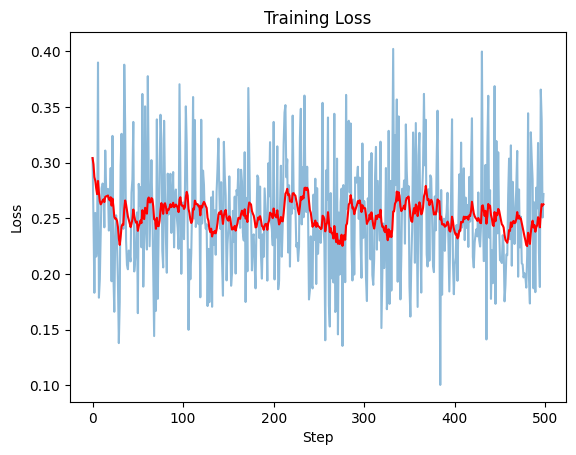

lr=2.50e-04


In [14]:
model.config.use_cache = False

batch_size    = 4
accum_steps   = 4                      # 4 * 4 = 16 effective batch
learning_rate = 3e-4
warmup_steps  = 200
max_steps     = 2000
max_grad_norm = 1.0

optimizer = torch.optim.AdamW(lora_params, lr=learning_rate)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=max_steps)

collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)
train_loader = DataLoader(data, batch_size=batch_size, shuffle=True, collate_fn=collator)

model.train()

step = 0
for epoch in range(1):
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        out = model(**batch)
        loss = out.loss / accum_steps
        loss.backward()

        step += 1

        if step >= max_steps:
            break

        if step % accum_steps != 0:
            continue

        clip_grad_norm_(lora_params, max_grad_norm)

        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()

        loss_item = (loss.detach().float()).item()
        video.manual_use(loss_item)
        print(f"lr={scheduler.get_last_lr()[0]:.2e}")

model.eval()
model.config.use_cache = True

In [ ]:
там дальше на примерах видно, что он обучился малех. я больше 2х часов не могу его уже обучать. 2й день уже на это обучение потратил, походу так и не подобрал оптимальные параметры, или тут не 2ч, а 20ч надо дать хз :smile-face:

In [20]:
lora_model_outputs: dict[str, str] = {}

for prompt in prompts:
    batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device) if prompt else {}

    output_ix = model.generate(
        **batch,
        max_new_tokens=50,
        do_sample=False,           # we could do `do_sample=True`, but will do `do_sample=False` with
        repetition_penalty=1.2,
    )

    lora_model_outputs[prompt] = tokenizer.decode(output_ix.flatten().tolist(), skip_special_tokens=True)
    print(f"Prompt - {prompt}:\n{lora_model_outputs[prompt]}")
    print("#" * 100, "\n\n")

clear_output()


In [21]:
import pickle

with open("basic_model_outputs.pkl", "wb") as f:
    pickle.dump(basic_model_outputs, f)

with open("lora_model_outputs.pkl", "wb") as f:
    pickle.dump(lora_model_outputs, f)

In [22]:
# This template helps to compare generated code samples in pretty table form
# feel free to present your work in other forms

from IPython.display import HTML, display
table_template = """<table style="border:1px solid black" >
  <tr>
    <th style="text-align: center; border:1px solid black">PROMPT</th>
    <th style="text-align: center; border:1px solid black">BEFORE</th>
    <th style="text-align: center; border:1px solid black">AFTER</th>
  </tr>
{}
</table>"""

row_template = '''  <tr>
    <td style="width:20%; border:1px solid black"><pre align="left">`{}`</pre></td>
    <td style="width:40%; border:1px solid black"><pre align="left">{}</pre></td>
    <td style="width:40%; border:1px solid black"><pre align="left">{}</pre></td>
  </tr>'''

rows = []

for prompt in prompts:
    rows.append(row_template.format(prompt, basic_model_outputs[prompt], lora_model_outputs[prompt]))

display(HTML(table_template.format('\n'.join(rows))))

PROMPT,BEFORE,AFTER
``,"Human的定义是什么？ 在人类中，""definition of human in the context of humans and their experiences within a broader framework, including but not limited to biological processes such as reproduction. In simpler terms for non-biologists: 'What does it","Human """""" # -*- coding: utf-8 -*- # import logging from django.core.exceptions import PermissionDenied, ValidationError logger = logging.getLogger(__name__) def get_object_or_permission_denied(model_class=None, object_id=None): """""""
`import`,"import { async, ComponentFixture, TestBed } from '@angular/core/testing'; import { AdminDashboardComponent } from './admin-dashboard.component'; // import * as firebaseAdminMockedModule describe('AdminDashboardComponent', () => { let component: AdminDashboard","import { Component, } from '@angular/core'; // import { // IonicPage, NavController, NavParams } from 'ionic-angular'; @Component({ templateUrl: './home.html' }) export class HomePage { } /* Copyright (c) 20"
`from`,"from \eqref{Eq:Gauss} and the fact that $p$ is a Gaussian. \endproof The following lemma shows how to compute $\mathbb E_{q_\theta}[f(\boldsymbol x)]$, where","from __future__ import absolute_import import os # This is the path to your project's root directory. PROJECT_ROOT = lambda *x: os.path.join(os.environ['HOME'], 'projects', x[0]) DEBUG = True DATABASES"
`while`,"while \n\telse\n\techo ""Error: Invalid input. Please enter a valid number."" >&2 return 1 # Return an error code to indicate failure fi done < ""$input_file""","while (True): try: n = int(input()) if(n == 0 or n < -15.9876 and n > +234.56): print(""Fora de intervalo"")"
`try`,"try \n\t"" + "" if (a == 0) {\r\n"" + ""\tthrow new RuntimeException(\""test\"");}\r\n""+ ""}\r""); } }","try: from setuptools import setup except ImportError as e: # pragma: no cover (setuptools is always installed) raise RuntimeError(""Could not find 'setup.py' in the parent directory. "" ""Please run this script with `"
`if`,"if \(\frac{a}{b} = 3\) and \(c - b + d^2=0\), what is the value of c in terms of a, if we know that $d=\sqrt{\left|\log_{1","if __name__ == '__main__': n = int(input()) for i in range(1, 20): print(i**n) if (i ** n < pow(n+5,n)) else break # for j"
`for`,"for \(\alpha > 0\), where \(a\) and \(b\) are positive constants. This equation describes the behavior of a system with long-range interactions, such as those found in certain types of plasmas or self-gravitating systems",for _ in range(int(input())): n = int(input()) if (n == 1): print(0) elif(n %2 != 0 and ((3*n+5)//8) > (((4*(n
`torch`,torch \n torch::nn 在C++中使用PyTorch进行深度学习模型的训练和推理通常涉及到以下几个步骤。这里假设您已经安装了`pybind11-torch-cpp-example`库，并且您的项目结构,"torch::Tensor get_tensor_from_buffer(const std::vector& buffer, const torch::Device& device) { auto tensor = aten_to_torch(buffer); #ifdef USE_CUDA if (device.type() == ""cuda"") {"
`except`,except \n if (i == 0 || i > s.length() - k) { continue; } // check for the condition where we have to remove a character from string. if ((s[i] != \'a,"except __name__ == ""__main__"": pass import sys, os sys.path.append(os.getcwd()) from src import * # from .src import * def main(): # print(""Hello World"") if (__name__)==""__main"
`assert`,"assert \in_array($type, ['text', 'image']); php中这个方法是什么意思 在 PHP 中，`\` 符号用于指定命名空间。在这个例子中的 `\`, 实际上是多余的，并且通常不会出现在标准","assert __name__ == ""__main__"" or exit() ### LIB ### from base64 import b32decode import os, sys sys.path.append(os.getcwd()) # from lib.terminal_colors import * try: # Python 3"


If you reach this: congratulations! you've completed everything in this practice session.

If you want to dig deeper, try to implement prompt-tuning (for bonus points!).
You can read more about prompt tuning variants in paper [1](https://arxiv.org/abs/2104.08691) or paper [2](https://arxiv.org/abs/2101.00190). Both versions can be implemented by passing trainable prompts as `model.forward(..., past_key_values=your_prompts)`.



### Read more

* How post-training quantization works: https://arxiv.org/abs/2208.07339
* An overview of running large models: https://huggingface.co/docs/accelerate/package_reference/big_modeling
* A general library for different adapter types: https://adapterhub.ml/


### [extra info] Running other models.

This notebook's code can run with other models of similar size, such as [Falcon-7B](https://huggingface.co/tiiuae/falcon-7b), [OPT-6.7B](https://huggingface.co/facebook/opt-6.7b) or [BLOOM-7.1B](https://huggingface.co/bigscience/bloom-7b1). However, they will require minor code tweaks:
1. change the model name in `AutoModelForCausalLM.from_pretrained()` __and__ `AutoTokenizer`
2. In the prompt tuning code, change `model.model.embed_tokens` to refer to the target model's word embeddings. Simply `print(model)` to navigate to them.
3. Change code to add Lora layers - specifically where you what the transformer block components, since those components now have different names.